# Greek Protipa Exams Dataset: EDA & Samples

This notebook demonstrates how to load the **Greek Protipa Exams** dataset from Hugging Face, inspect samples, and perform Exploratory Data Analysis (EDA) using specialized utility functions.

In [7]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
from protipa_exams_dataset.eda_utils import display_qa
from dotenv import load_dotenv, find_dotenv
import numpy as np
import random

from protipa_exams_dataset.eda_utils import (
    print_sample, 
    display_samples,
    display_multimodal_samples, 
    plot_subject_dist,      # New (separated)
    plot_level_dist,        # New (separated)
    plot_format_dist,       # New (separated)
    plot_reference_dist,     # New (separated)
    plot_temporal_distribution,
    plot_points_distribution,


)

# Load environment variables
load_dotenv(find_dotenv())

repo_id = os.getenv("HF_REPO_ID")
token = os.getenv("HF_TOKEN")

print(f"Using Repository: {repo_id}")



Using Repository: ilsp/greek-protipa-exams


## 1. Load the Dataset
We load the `test` split, which contains the consolidated data.

In [9]:
dataset = load_dataset(repo_id, split="test", token=token)
df = dataset.to_pandas()

print(f"✅ Dataset loaded. Total rows: {len(df)}")

✅ Dataset loaded. Total rows: 1646


## 2. Inspect Samples
We use the `display_samples` utility to look at a few random questions in detail.

In [10]:
target_id = "math_lyc_2013_2_5.1"
# print_sample(df, target_id)
#df[df['id'] == target_id]

# 2. Use it simply
random_id = random.choice( ['math_lyc_2016_1_10.2', 'math_lyc_2016_2_9.2', 'math_lyc_2016_0_9.1', 'math_lyc_2016_1_10.2', 'math_lyc_2016_2_9.2', 'math_lyc_2016_2_10.2'])

display_qa(df, random_id)


In [15]:
display_samples(df, n=3, truncate=True)

id,subject,year,admission_level,question,input,image,choices,answer_text,answer_index
greek_language_gym_2024_1_17,greek_language,2024,gymnasium,Η λέξη που μπορεί να αντικαταστήσει τη λέξη «προάγγελος» είναι:,"Κείμενο Β: Μάρια Μπαχά, Μια ιστορία για τον Διονύσιο Σολωμό, Καλειδοσκόπιο, Αθήνα 2021, σελ. 75-76 ...",,• Α. Προμήνυμα• Β. Προαίσθηση• Γ. Παραίσθηση• Δ. Προϋπόθεση,A,0
greek_language_lyc_2020_8_1,greek_language,2020,lyceum,"Ποια από τις παρακάτω προτάσεις είναι σωστή, σύμφωνα με το νόημα του κειμένου;","Κείμενο: «Μέσα στα δάση της Ηπείρου» Το πειραματικό ντοκιμαντέρ μικρού μήκους ""Forest of Tranquilit...",,• Α. Ο κινηματογραφιστής ήταν εύκολο να προσεγγίσει τις τοποθεσίες που επισκέφθηκε.• Β. Ο κινηματογραφιστής δεν απέκλειε την ανθρώπινη παρουσία από τις σκηνές που αποτύπωνε.• Γ. Οι τοποθεσίες του ντοκιμαντέρ είναι άγνωστες στο ευρύ κοινό.• Δ. Χρειάστηκε να γίνει μεταγενέστερη επεξεργασία στον ήχο της φύσης.,Γ,2
math_lyc_2013_1_1.3,mathematics,2013,lyceum,Δίνεται η αλγεβρική παράσταση$$A=(x-y)(x+2y)+(x+y)^{2}+(x-2y)^{2}-5xy$$ Να αποδείξετε ότι η παραπά...,,,,"$$A=(x-y)(x+2y)+(x+y)^{2}+(x-2y)^{2}-5xy$$, $$A=x^{2}+2xy-xy-2y^{2}+x^{2}+2xy+y^{2}+x^{2}-4xy+4y^{2}...",


## 3. Multimodal Analysis (Samples with Images)
Let's specifically look at questions that include visual aids. We display them as a DataFrame first, then show the images.

id,subject,year,admission_level,question,input,image,choices,answer_text,answer_index
math_gym_2018_1_7,mathematics,2018,gymnasium,"Τα 400 παιδιά ενός δημοτικού σχολείου της Αθήνας συμμετείχαν σε μια έρευνα στην οποία δήλωσαν τις προτιμήσεις τους σε αθλήματα. Οι απαντήσεις που έδωσαν φαίνονται στο παρακάτω κυκλικό διάγραμμα, στο οποίο σβήστηκαν τα ποσοστά των προτιμήσεων τους σε βόλεϊ και της επιλογής τους «άλλο άθλημα». Αν γνωρίζουμε ότι οι μαθητές που δήλωσαν «άλλο άθλημα» είναι τριπλάσιοι από όσους δήλωσαν «βόλεϊ», τότε οι μαθητές που δήλωσαν «βόλεϊ» είναι:",,,• Α. 25• Β. 75• Γ. 100• Δ. 150• Ε. 180,Α,0
math_gym_2020_3_30,mathematics,2020,gymnasium,Παρατήρησε τις παρακάτω ζυγαριές που ισορροπούν. Πόσο ζυγίζουν τα κρεμμύδια;,,,• Α. 14 κιλά• Β. 16 κιλά• Γ. 32 κιλά• Δ. 24 κιλά,Β,1
math_gym_2018_2_1,mathematics,2018,gymnasium,Στο παρακάτω σχήμα ένα πάτωμα σχήματος τετράγωνου και πλευράς 5 μ. έχει χωριστεί σε άσπρα και μαύρα τετράγωνα πλευράς 1μ. Το συνολικό εμβαδόν των μαύρων τετραγώνων είναι,,,"• Α. 12,5 τ.μ• Β. 15 τ.μ• Γ. 16 τ.μ• Δ. 20 τ.μ• Ε. 20 τ.μ",Γ,2

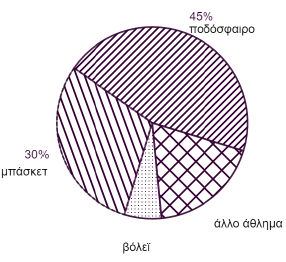
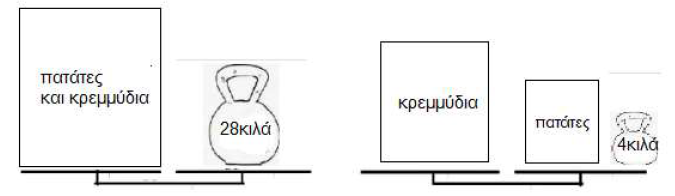
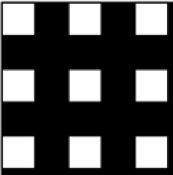

In [13]:
display_samples(df, n=3, prioritize_images=True)

## 4. Exploratory Data Analysis (EDA)

### 4.1 Distribution by Subject and Admission Level

In [ ]:

# Subject Distribution
fig_subj, df_subj = plot_subject_dist(df)
display(df_subj)
display(fig_subj)

In [ ]:
# Admission Level Distribution
fig_level, df_level = plot_level_dist(df)
display(df_level)
display(fig_level)

### 4.2 Distribution by Format and Reference Type

In [ ]:
# Question Format Distribution
fig_format, df_format = plot_format_dist(df)
display(df_format)
display(fig_format)

In [ ]:
# Reference Type Distribution
fig_ref, df_ref = plot_reference_dist(df)
display(df_ref)
display(fig_ref)

### 4.3 Temporal Trends
How are questions distributed over the years per subject?

In [ ]:
fig_temp, df_temp = plot_temporal_distribution(df)
display(df_temp)
display(fig_temp)

### 4.4 Point Values Analysis

In [ ]:
fig_points, df_points = plot_points_distribution(df)
display(df_points)
display(fig_points)

In [ ]:
from protipa_exams_dataset.eda_utils import plot_format_by_subject
# Returns the matplotlib figure and the pivot table of counts
fig_fmt, df_fmt = plot_format_by_subject(df)
display(fig_fmt)
display(df_fmt)

### 4.5 Unique verification

In [ ]:

# Create a temporary series where 'choices' are tuples so they can be hashed/compared
choices_hashable = df['choices'].apply(lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x)

# 1. Total duplicates (Metadata + Choices)
# We find all standard hashable columns and manually include the converted choices
metadata_cols = [col for col in df.columns if df[col].apply(lambda x: not isinstance(x, (list, np.ndarray))).all()]
check_subset = metadata_cols + (['choices'] if 'choices' in df.columns else [])

# We use assign to temporarily hold the hashable choices for the check
total_duplicates = df.assign(choices=choices_hashable).duplicated(subset=check_subset).sum()
print(f"Total duplicate rows (Metadata + Choices): {total_duplicates}")

# 2. Check uniqueness of the 'id' column
if 'id' in df.columns:
    is_id_unique = df['id'].is_unique
    print(f"Is 'id' column unique? {is_id_unique}")
    if not is_id_unique:
        num_duplicates = df.duplicated('id').sum()
        print(f"Number of duplicate IDs: {num_duplicates}")


# 3. Check for rows with identical [Question + Choices + Input]
# This defines a "Semantic Duplicate" (same content, regardless of ID/Year)
subset_to_check = []
if 'question' in df.columns: subset_to_check.append('question')
if 'input' in df.columns:    subset_to_check.append('input')
subset_to_check.append('c_h') # This is our tuple-version of choices

content_duplicates = df.assign(c_h=choices_hashable).duplicated(subset=subset_to_check).sum()

print(f"Rows with identical content ({' + '.join([c if c!='c_h' else 'choices' for c in subset_to_check])}): {content_duplicates}")

# Optional: To actually see them
if content_duplicates > 0:
    print("\nDisplaying samples of content duplicates:")
    dup_rows = df.assign(c_h=choices_hashable)[df.assign(c_h=choices_hashable).duplicated(subset=subset_to_check, keep=False)]
    display(dup_rows.sort_values(by='question')[['id', 'subject', 'year', 'question', 'input']])

# 4. Check for nulls in critical columns
critical_cols = ['id', 'subject', 'admission_level', 'question']
existing_critical = [c for c in critical_cols if c in df.columns]
null_counts = df[existing_critical].isnull().sum()

if null_counts.sum() > 0:
    print("\nNull values in critical columns:")
    print(null_counts[null_counts > 0])
else:
    print(f"\n✅ No null values in critical columns ({', '.join(existing_critical)}).")

In [ ]:
# Filter for duplicate questions
duplicate_questions_df = df[df.duplicated(subset=['question'], keep=False)].sort_values(by='question')

# Display with specific CSS for wrapping and column width
(duplicate_questions_df[['id', 'subject', 'year', 'question']]
 .style.set_properties(**{
     'text-align': 'left',
     'white-space': 'pre-wrap',  # Correctly handles newlines and wrapping
     'max-width': '600px',       # Limits width so it doesn't stretch the screen
     'vertical-align': 'top'
 }))

In [ ]:
# 1. Find rows with literal \n (legacy escaped newlines)
literal_nl_mask = df['answer_text'].str.contains(r'\\n', regex=True, na=False)
literal_nl_ids = df[literal_nl_mask]['id'].tolist()
# 2. Find rows with stringified JSON lists ["...", "..."]
json_list_mask = df['answer_text'].str.startswith('[', na=False) & df['answer_text'].str.endswith(']', na=False)
json_list_ids = df[json_list_mask]['id'].tolist()
# 3. Find "True" multi-line answers (already using real newlines)
true_multiline_mask = df['answer_text'].str.contains('\n', na=False)
true_multiline_ids = df[true_multiline_mask]['id'].tolist()
print(f"📊 Rows with literal '\\n': {len(literal_nl_ids)}")
print(f"IDs: {literal_nl_ids[:10]} ...\n")
print(f"📦 Rows with stringified lists: {len(json_list_ids)}")
print(f"IDs: {json_list_ids[:10]} ...\n")
print(f"✅ Rows already using real newlines: {len(true_multiline_ids)}")
print(f"IDs: {true_multiline_ids[:10]} ...")

In [ ]:
import random

# Load a random sample
random_idx = random.randint(0, len(dataset) - 1)
sample = dataset[random_idx]

print(f"Sample Index: {random_idx} | ID: {sample['id']}")
print(f"Question: {sample['question']}\n")

# 1. Handle Multimodal Metadata (Descriptions & Transcriptions)
if sample.get('image_description'):
    print(f"🖼️  Image Description: {sample['image_description']}")

if sample.get('image_transcription'):
    print(f"📝 Image Transcription: {sample['image_transcription']}")

# 2. Handle Choices
if sample.get('choices'):
    print("\nChoices:")
    correct_idx = sample.get('answer_index')
    for i, choice in enumerate(sample['choices']):
        marker = "[✅]" if i == correct_idx else "[  ]"
        print(f"  {marker} {i}: {choice}")
    print(f"\nCorrect Answer Index: {correct_idx}")
else:
    print(f"\nAnswer: {sample['answer_text']}")